In [236]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Sysgen/InsDelGLM


In [334]:
from pathlib import Path

import torch
from modules.custom_bert import DNABertForMaskedLM
from modules.dna_tokenizer import DNATokenizer

model_dir = "../model/Panther_deletion_100k_1e-5"

tokenizer = DNATokenizer.from_pretrained(model_dir)
model = DNABertForMaskedLM.from_pretrained(model_dir)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("Loaded model from:", Path(model_dir).resolve())
print("Device:", device)
print("Vocab size:", model.config.vocab_size)
print("Mask token id:", tokenizer.mask_token_id)
print("Pad token id:", tokenizer.pad_token_id)
print("Example tokens:", tokenizer("ACGT-")["input_ids"])

Loaded model from: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Sysgen/InsDelGLM/model/Panther_deletion_100k_1e-5
Device: cpu
Vocab size: 9
Mask token id: 6
Pad token id: 5
Example tokens: tensor([[7, 0, 2, 3, 1, 4, 8, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

In [238]:
import numpy as np
import pandas as pd
import torch

# 1) load test set
df = pd.read_parquet("../data/simulated/old_test.parquet")
seqs = df["sequences"].tolist()
print("n_test:", len(seqs))
print("example seq:", seqs[0][:80])

# 2) load motifs
with open("../data/simulated/old_motifs.txt") as f:
    motif_a = f.readline().strip()
    motif_b = f.readline().strip()

print("motif_a:", motif_a, "len=", len(motif_a))
print("motif_b:", motif_b, "len=", len(motif_b))

n_test: 20000
example seq: CAG-TGTAACGCTCCCGCATACGAACTAGT
motif_a: CGTAGGTC len= 8
motif_b: GTAACGCTCC len= 10


In [239]:
mask_id = tokenizer.mask_token_id
pad_id = tokenizer.pad_token_id

# gap token id ( '-' )
gap_id = tokenizer("-")["input_ids"][0][1]

# nucleotide token ids
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]

print(
    "IDs:",
    {
        "A": A_id,
        "C": C_id,
        "G": G_id,
        "T": T_id,
        "-": gap_id,
        "[MASK]": mask_id,
        "[PAD]": pad_id,
    },
)

IDs: {'A': tensor(0), 'C': tensor(2), 'G': tensor(3), 'T': tensor(1), '-': tensor(4), '[MASK]': 6, '[PAD]': 5}


In [240]:
def find_motif_pos(seq, motif):
    return seq.find(motif)


def show_context(seq, start, motif, flank=8):
    """Show motif with left/right flanks for readability."""
    if start < 0:
        return None
    left = seq[max(0, start - flank) : start]
    mid = seq[start : start + len(motif)]
    right = seq[start + len(motif) : start + len(motif) + flank]
    return f"{left}[{mid}]{right}"


def spacing_between_motifs(seq, a_start, motif_a, b_start, motif_b):
    """
    Compute spacing between motif A and motif B.
    - char_spacing: raw character distance from end(A) to start(B)
    - nuc_spacing: distance counting only A/C/G/T (excluding '-')
    """
    a_end = a_start + len(motif_a)
    b_begin = b_start

    if a_start < 0 or b_start < 0:
        return None, None
    if b_begin < a_end:
        return None, None  # overlapping or invalid order

    between = seq[a_end:b_begin]  # substring between motifs
    char_spacing = len(between)
    nuc_spacing = sum(ch in ["A", "C", "G", "T"] for ch in between)  # exclude '-'

    return char_spacing, nuc_spacing


n_show = 10
shown = 0

for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)

    # only show sequences where BOTH motifs exist and B is after A
    if pa >= 0 and pb >= 0 and pb > pa:
        char_sp, nuc_sp = spacing_between_motifs(s, pa, motif_a, pb, motif_b)
        if char_sp is None:
            continue

        print(f"\nexample {shown+1}")
        print("FULL SEQUENCE:", s)  # show the entire sequence in one line
        print("motif A start:", pa, "| motif B start:", pb)
        print("A context:", show_context(s, pa, motif_a, flank=10))
        print("B context:", show_context(s, pb, motif_b, flank=10))

        # spacing (A end -> B start)
        print("spacing (chars, includes '-'): ", char_sp)
        print("spacing (nucleotides only, excludes '-'): ", nuc_sp)

        shown += 1
        if shown >= n_show:
            break

print("\nShown:", shown)


example 1
FULL SEQUENCE: ACGTAGGTCCTTAAAG-AGCGTAACGCTCC
motif A start: 1 | motif B start: 20
A context: A[CGTAGGTC]CTTAAAG-AG
B context: TTAAAG-AGC[GTAACGCTCC]
spacing (chars, includes '-'):  11
spacing (nucleotides only, excludes '-'):  10

example 2
FULL SEQUENCE: CGTAGGTCG-GAGTCCGT-GGTAACGCTCC
motif A start: 0 | motif B start: 20
A context: [CGTAGGTC]G-GAGTCCGT
B context: GAGTCCGT-G[GTAACGCTCC]
spacing (chars, includes '-'):  12
spacing (nucleotides only, excludes '-'):  10

example 3
FULL SEQUENCE: -CGTAGGTCAAGGGAAGT-CGTAACGCTCC
motif A start: 1 | motif B start: 20
A context: -[CGTAGGTC]AAGGGAAGT-
B context: AGGGAAGT-C[GTAACGCTCC]
spacing (chars, includes '-'):  11
spacing (nucleotides only, excludes '-'):  10

example 4
FULL SEQUENCE: CGTAGGTCGCGTGAAGCCGTAACGCTCCTG
motif A start: 0 | motif B start: 18
A context: [CGTAGGTC]GCGTGAAGCC
B context: GCGTGAAGCC[GTAACGCTCC]TG
spacing (chars, includes '-'):  10
spacing (nucleotides only, excludes '-'):  10

example 5
FULL SEQUENCE: GCGTAG

In [241]:
import torch
import torch.nn.functional as F

# --- token ids we care about ---
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]
gap_id = tokenizer("-")["input_ids"][0][1]

mask_id = tokenizer.mask_token_id
pad_id = tokenizer.pad_token_id

VOCAB_IDS = [A_id, C_id, G_id, T_id, gap_id]
VOCAB_CHS = ["A", "C", "G", "T", "-"]


def probs_at_position(sequence: str, pos_char: int, max_length: int = 64):
    """
    Returns model probabilities for A/C/G/T/- at a given character position.
    IMPORTANT: We do NOT insert "[MASK]" into the raw string.
               We mask directly in token ids to avoid DNATokenizer errors.
    """
    # --- bounds check ---
    if pos_char < 0 or pos_char >= len(sequence):
        return None

    # --- tokenize the original sequence (no masking in the string) ---
    enc = tokenizer(sequence, max_length, padding="max_length", return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}

    input_ids = enc["input_ids"].clone()  # [1, L]
    attn_mask = enc["attention_mask"].clone()  # [1, L]

    # DNATokenizer adds [CLS] at token index 0, so shift by +1
    pos_tok = pos_char + 1
    if pos_tok >= input_ids.shape[1]:
        return None

    # --- mask the token directly in input_ids ---
    input_ids[0, pos_tok] = mask_id

    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attn_mask)

    logits = out.logits if hasattr(out, "logits") else out[0]  # [1, L, V]
    probs_full = F.softmax(logits[0, pos_tok], dim=-1)  # [V]

    # --- return only A/C/G/T/- probabilities ---
    probs = {ch: float(probs_full[_id].item()) for ch, _id in zip(VOCAB_CHS, VOCAB_IDS)}
    return probs

Selected example length: 30
motif A start: 1 | motif B start: 20
A context: A[CGTAGGTC]CTTAAAG-AG
B context: TTAAAG-AGC[GTAACGCTCC]
tokenized length L: 32


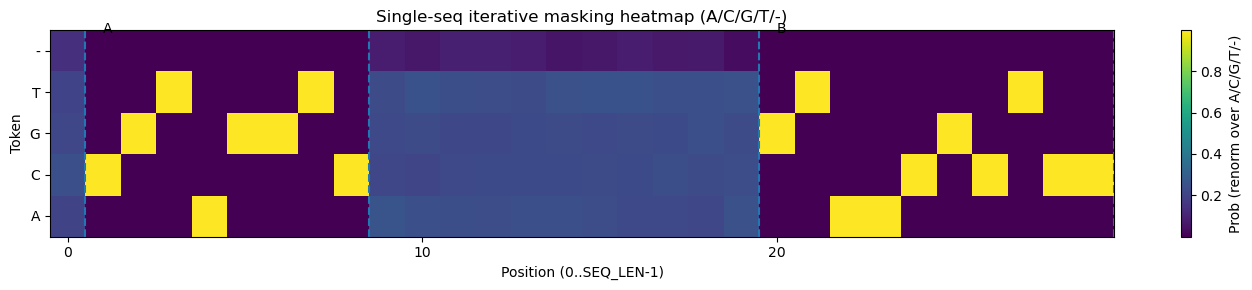

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


example_seq = None
pa = pb = -1

for s in seqs:
    pa_ = find_motif_pos(s, motif_a)
    pb_ = find_motif_pos(s, motif_b)
    if pa_ >= 0 and pb_ >= 0 and pb_ > pa_:
        example_seq = s
        pa, pb = pa_, pb_
        break

assert example_seq is not None, "No sequence found that contains BOTH motifs A and B in order."

print("Selected example length:", len(example_seq))
print("motif A start:", pa, "| motif B start:", pb)
print("A context:", show_context(example_seq, pa, motif_a, flank=10))
print("B context:", show_context(example_seq, pb, motif_b, flank=10))

SEQ_LEN = len(example_seq)        
MAX_LEN = SEQ_LEN + 2              

VOCAB_CHS = ["A", "C", "G", "T", "-"]
VOCAB_IDS_T = torch.tensor([A_id, C_id, G_id, T_id, gap_id], device=device, dtype=torch.long)

enc = tokenizer([example_seq], MAX_LEN, padding="max_length", return_tensors="pt")
input_ids0 = enc["input_ids"].to(device)          # [1, L]
attn0      = enc["attention_mask"].to(device)     # [1, L]
L = input_ids0.shape[1]

print("tokenized length L:", L)

heat_one = np.zeros((SEQ_LEN, 5), dtype=np.float64)

for pos_char in range(SEQ_LEN):
    pos_tok = pos_char + 1  # CLS shift
    if pos_tok >= L:
        continue

    ids = input_ids0.clone()
    ids[0, pos_tok] = mask_id

    with torch.no_grad():
        out = model(input_ids=ids, attention_mask=attn0)
    logits = out.logits if hasattr(out, "logits") else out[0]   # [1, L, V]

    probs_full = F.softmax(logits[0, pos_tok], dim=-1)          # [V]
    p5 = probs_full.index_select(dim=0, index=VOCAB_IDS_T)      # [5]

    # 5개로 renorm (권장)
    p5 = p5 / (p5.sum() + 1e-12)

    heat_one[pos_char] = p5.detach().cpu().numpy()

# ----------------------------
# 3) plot (single sample)
# ----------------------------
plt.figure(figsize=(14, 3))
plt.imshow(heat_one.T, aspect="auto", origin="lower")
plt.colorbar(label="Prob (renorm over A/C/G/T/-)")
plt.yticks(range(5), VOCAB_CHS)
plt.xticks(range(0, SEQ_LEN, 10))
plt.xlabel("Position (0..SEQ_LEN-1)")
plt.ylabel("Token")
plt.title("Single-seq iterative masking heatmap (A/C/G/T/-)")

plt.axvline(pa - 0.5, linestyle="--")
plt.axvline(pa + len(motif_a) - 0.5, linestyle="--")
plt.text(pa, 4.7, "A", va="top")

plt.axvline(pb - 0.5, linestyle="--")
plt.axvline(pb + len(motif_b) - 0.5, linestyle="--")
plt.text(pb, 4.7, "B", va="top")

plt.tight_layout()
plt.show()

In [211]:
s = seqs[0]

print("Sequence:", s)
print("Length:", len(s))
print("True base at pos 10:", s[10])

probs = probs_at_position(s, pos_char=10)
print("Predicted probs:", probs)

Sequence: CAG-TGTAACGCTCCCGCATACGAACTAGT
Length: 30
True base at pos 10: G
Predicted probs: {'A': 0.0003282313118688762, 'C': 0.00041161442641168833, 'G': 0.9981958270072937, 'T': 0.00044882859219796956, '-': 0.0006003553862683475}


In [ ]:
from collections import defaultdict

def find_motif_pos(seq, motif):
    return seq.find(motif)

# key = (pa, pb)
groups_ab = defaultdict(list)

for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)
    if pa >= 0 and pb >= 0 and pb > pa:
        groups_ab[(pa, pb)].append(s)

print("num groups:", len(groups_ab))

top = sorted(groups_ab.items(), key=lambda kv: len(kv[1]), reverse=True)[:10]
for (pa, pb), lst in top:
    print((pa, pb), "n=", len(lst))


(pa0, pb0), subset_all = top[3]
N = 50
subset = subset_all[:N]

print("\nSelected group:", (pa0, pb0), "n=", len(subset))

num groups: 6
(0, 20) n= 730
(1, 20) n= 696
(0, 19) n= 605
(2, 20) n= 340
(1, 19) n= 309
(0, 18) n= 242

Selected group: (2, 20) n= 50


In [216]:
import numpy as np
import torch
from tqdm import tqdm

def logits_to_log_odds(logits_np):
    """
    logits_np: (..., 4) over A,C,G,T
    return: log(p/(1-p)) per base
    """
    # log_softmax in numpy
    x = logits_np - logits_np.max(axis=-1, keepdims=True)
    logp = x - np.log(np.exp(x).sum(axis=-1, keepdims=True))  # log softmax
    # log(1-p) in stable way
    p = np.exp(logp)
    log1mp = np.log1p(-p + 1e-12)
    return logp - log1mp

def check_acgt_only(seq):
    return all(ch in "ACGT" for ch in seq)

def replace_gaps_random(seq, seed=0):
    import random
    rng = random.Random(seed)
    return "".join(rng.choice("ACGT") if ch == "-" else ch for ch in seq)

def make_dataset_gap_only(sequence, L, do_reconstruction=False):
    """
    Return a list of (kind, i) entries to generate samples in fixed order.
    kind:
      - "ref": reference (no mask)
      - "mask": mask position i (for reconstruction or masking-style)
      - "mutgap": mutate position i -> gap (no mask)
    For GAP-ONLY dependency by mutation, we need:
      ref + (optional masked for reconstruction) + mutgap for all i
    """
    items = [("ref", None)]
    if do_reconstruction:
        for j in range(L):
            items.append(("mask", j))
    for i in range(L):
        items.append(("mutgap", i))
    return items

In [217]:
# ---- IDs ----
mask_id = int(tokenizer.mask_token_id)
gap_id  = int(tokenizer("-")["input_ids"][0][1])

A_id = int(tokenizer("A")["input_ids"][0][1])
C_id = int(tokenizer("C")["input_ids"][0][1])
G_id = int(tokenizer("G")["input_ids"][0][1])
T_id = int(tokenizer("T")["input_ids"][0][1])
ACGT_IDS = torch.tensor([A_id, C_id, G_id, T_id], device=device, dtype=torch.long)

def tokenize_one(seq, MAX_LEN):
    # DNATokenizer: positional max_length
    enc = tokenizer(seq, MAX_LEN, padding="max_length", return_tensors="pt")
    return {
        "input_ids": enc["input_ids"].to(device),
        "attention_mask": enc["attention_mask"].to(device),
    }

@torch.no_grad()
def forward_logits_4(batch_dicts, L):
    # batch_dicts: list of {"input_ids": [1,T], "attention_mask":[1,T]}
    input_ids = torch.cat([b["input_ids"] for b in batch_dicts], dim=0)
    attn      = torch.cat([b["attention_mask"] for b in batch_dicts], dim=0)

    out = model(input_ids=input_ids, attention_mask=attn)
    logits_full = out.logits if hasattr(out, "logits") else out[0]  # [B,T,V]

    logits_seq = logits_full[:, 1:1+L, :]                           # [B,L,V] drop CLS
    logits_4   = logits_seq.index_select(dim=-1, index=ACGT_IDS)     # [B,L,4]

    return logits_4.detach().cpu().numpy()

In [219]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dependency_map.sequence_logo import SequenceLogo
from dependency_map.util import matplotlib_scale_as_plotly

def plot_like_dependency_map_lib(D, seq_logo, recon=None, title="DependencyMap (gap-only, lib-style)", zmin=0.0, zmax=5.0):
    L = D.shape[0]
    colorscale = matplotlib_scale_as_plotly("coolwarm")

    fig = make_subplots(rows=1, cols=1)
    Z = np.clip(D, zmin, zmax) if (zmin is not None or zmax is not None) else D

    fig.add_trace(
        go.Heatmap(x=np.arange(L), y=np.arange(L), z=Z, colorscale=colorscale, colorbar=dict(title="Dependency")),
        row=1, col=1
    )
    fig.update_xaxes(visible=False, scaleanchor="y", constrain="domain")
    fig.update_yaxes(visible=False, scaleanchor="x", constrain="domain", autorange="reversed")

    seq_logo_obj = SequenceLogo.from_sequence(seq_logo)

    if recon is not None:
        recon_logo = SequenceLogo.from_reconstruction(recon)

        # top: reconstruction
        fig.add_layout_image(
            source=recon_logo.to_svg(data_url=True),
            xref="x", yref="y domain",
            x=-0.5, y=1.0, sizex=L, sizey=0.10,
            xanchor="left", yanchor="bottom", sizing="stretch",
        )
        # left: sequence (west)
        fig.add_layout_image(
            source=seq_logo_obj.to_svg(data_url=True, orientation="west"),
            xref="x domain", yref="y",
            x=0.0, y=L-0.5, sizex=0.06, sizey=L,
            xanchor="right", yanchor="bottom", sizing="stretch",
        )
        # bottom: sequence (south)
        fig.add_layout_image(
            source=seq_logo_obj.to_svg(data_url=True, orientation="south"),
            xref="x", yref="y domain",
            x=-0.5, y=0.0, sizex=L, sizey=0.06,
            xanchor="left", yanchor="top", sizing="stretch",
        )
        # right: reconstruction (east)
        fig.add_layout_image(
            source=recon_logo.to_svg(data_url=True, orientation="east"),
            xref="x domain", yref="y",
            x=1.0, y=-0.5, sizex=0.10, sizey=L,
            xanchor="left", yanchor="top", sizing="stretch",
        )
    else:
        # top: sequence
        fig.add_layout_image(
            source=seq_logo_obj.to_svg(data_url=True),
            xref="x", yref="y domain",
            x=-0.5, y=1.0, sizex=L, sizey=0.06,
            xanchor="left", yanchor="bottom", sizing="stretch",
        )
        # right: sequence east
        fig.add_layout_image(
            source=seq_logo_obj.to_svg(data_url=True, orientation="east"),
            xref="x domain", yref="y",
            x=1.0, y=-0.5, sizex=0.06, sizey=L,
            xanchor="left", yanchor="top", sizing="stretch",
        )

    fig.update_layout(title=title, width=820, height=720, margin=dict(l=40, r=140, t=80, b=40))
    return fig

=== ORIGINAL (with gaps) ===
ACGTAGGTCCTTAAAG-AGCGTAACGCTCC
len: 30 | '-' count: 1
A@: 1 B@: 20

=== WINDOW USED ===
ACGTAGGTCCTTAAAG-AGCGTAACGCTCC
window len: 30
[gap-logodds-max5] done target j 5/30
[gap-logodds-max5] done target j 10/30
[gap-logodds-max5] done target j 15/30
[gap-logodds-max5] done target j 20/30
[gap-logodds-max5] done target j 25/30
[gap-logodds-max5] done target j 30/30
D shape: (30, 30) min/max: 0.0 0.7255749702453613


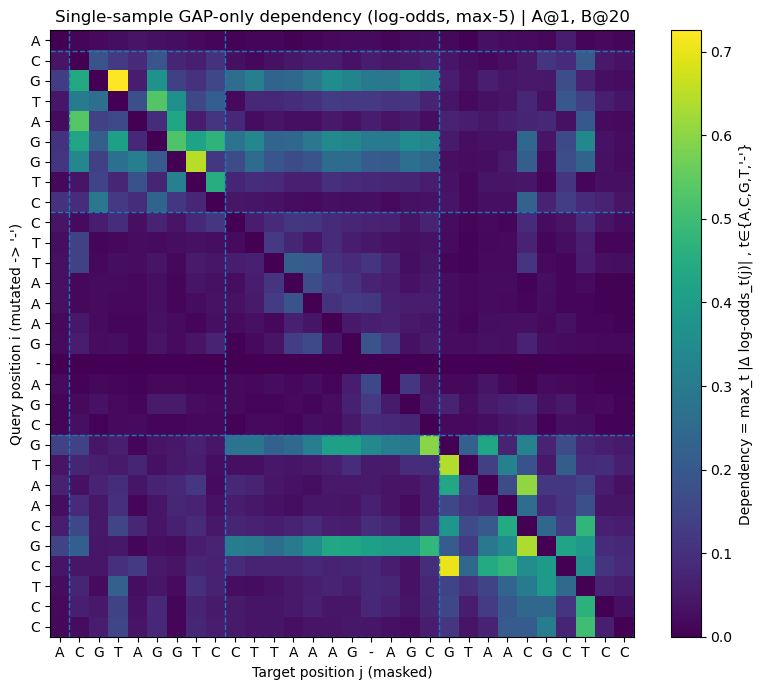

In [337]:
import numpy as np
import torch
import matplotlib.pyplot as plt

SEQ_LEN   = 30         # window length
MAX_LEN   = 64         # tokenizer max len (>= CLS + SEQ_LEN + padding)
A_START   = 1
B_START   = 20

mask_id = int(tokenizer.mask_token_id)

# IMPORTANT: vocab ids for the 5 tokens we care about (A,C,G,T,'-')
A_id   = int(tokenizer("A")["input_ids"][0][1])
C_id   = int(tokenizer("C")["input_ids"][0][1])
G_id   = int(tokenizer("G")["input_ids"][0][1])
T_id   = int(tokenizer("T")["input_ids"][0][1])
gap_id = int(tokenizer("-")["input_ids"][0][1])

VOCAB_IDS = [A_id, C_id, G_id, T_id, gap_id]
VOCAB_CHS = ["A", "C", "G", "T", "-"]

La, Lb = len(motif_a), len(motif_b)

def find_motif_pos(seq, motif):
    return seq.find(motif)

cands = []
for s in seqs:
    if find_motif_pos(s, motif_a) == A_START and find_motif_pos(s, motif_b) == B_START:
        cands.append(s)

if len(cands) == 0:
    raise ValueError(f"No sequence found with motif A@{A_START} and motif B@{B_START}.")

idx_pick = 0
example_seq = cands[idx_pick]

print("=== ORIGINAL (with gaps) ===")
print(example_seq)
print("len:", len(example_seq), "| '-' count:", example_seq.count("-"))
print("A@:", find_motif_pos(example_seq, motif_a), "B@:", find_motif_pos(example_seq, motif_b))

seq_window = example_seq[:SEQ_LEN]
if len(seq_window) < SEQ_LEN:
    raise ValueError("Sequence shorter than SEQ_LEN window.")
print("\n=== WINDOW USED ===")
print(seq_window)
print("window len:", len(seq_window))

subset = [example_seq]  # single sample

@torch.no_grad()
def forward_logits(input_ids, attention_mask):
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    return out.logits if hasattr(out, "logits") else out[0]  # [B, T, V]

def logit_from_logp(logp: torch.Tensor, eps: float = 1e-6):
    """
    logit(p) = log(p/(1-p)) computed stably from logp.
    """
    p = logp.exp()
    p = torch.clamp(p, eps, 1.0 - eps)
    return torch.log(p) - torch.log1p(-p)

# -----------------------------
# 3) core: GAP-only mutation, but score = max over 5 tokens of |Δ log-odds|
#    Baseline for each j: mask j ONLY
#    Mutation for (i,j): mask j AND set i -> gap
#    For each condition, compute log-odds for each token in {A,C,G,T,'-'} at position j.
# -----------------------------
def dependency_map_gap_logodds_max5_single(
    seqs_subset,
    seq_len=SEQ_LEN,
    max_len=MAX_LEN,
    zero_diagonal=True,
    skip_if_i_already_gap=True,   # if i is already '-', set D[i,j]=0 (same as your earlier behavior)
):
    model.eval()
    N = len(seqs_subset)
    assert N == 1, "This function is for single-sample usage."

    D = np.zeros((seq_len, seq_len), dtype=np.float64)

    enc = tokenizer(seqs_subset, max_len, padding="max_length", return_tensors="pt")
    input_ids0 = enc["input_ids"].to(device)          # [1, T]
    attn0      = enc["attention_mask"].to(device)

    # --- baseline log-odds vectors for each j: shape [seq_len, 5] ---
    base_logodds = np.zeros((seq_len, len(VOCAB_IDS)), dtype=np.float64)

    for j in range(seq_len):
        ids = input_ids0.clone()
        j_tok = j + 1
        ids[:, j_tok] = mask_id

        logits = forward_logits(ids, attn0)                           # [1, T, V]
        logp   = torch.log_softmax(logits[:, j_tok, :], dim=-1)[0]    # [V]
        # log-odds per token
        logodds = []
        for tid in VOCAB_IDS:
            logodds.append(float(logit_from_logp(logp[tid]).item()))
        base_logodds[j, :] = np.array(logodds, dtype=np.float64)

    # --- mutated: for each (i,j) do i->gap, j masked, compare log-odds vectors at j ---
    for j in range(seq_len):
        for i in range(seq_len):
            if i == j and zero_diagonal:
                D[i, j] = 0.0
                continue

            ids = input_ids0.clone()
            # mask target j
            ids[:, j + 1] = mask_id

            # mutate query i -> gap (if it actually changes)
            orig_i = int(ids[0, i + 1].item())
            if skip_if_i_already_gap and orig_i == gap_id:
                D[i, j] = 0.0
                continue
            ids[0, i + 1] = gap_id

            logits = forward_logits(ids, attn0)
            logp   = torch.log_softmax(logits[:, j + 1, :], dim=-1)[0]  # [V]

            mut_logodds = np.zeros((len(VOCAB_IDS),), dtype=np.float64)
            for k, tid in enumerate(VOCAB_IDS):
                mut_logodds[k] = float(logit_from_logp(logp[tid]).item())

            # score: max over tokens of absolute log-odds change
            D[i, j] = float(np.max(np.abs(base_logodds[j, :] - mut_logodds)))

        if (j + 1) % 5 == 0:
            print(f"[gap-logodds-max5] done target j {j+1}/{seq_len}")

    if zero_diagonal:
        np.fill_diagonal(D, 0.0)

    return D

# ---- compute D ----
D = dependency_map_gap_logodds_max5_single(subset, seq_len=SEQ_LEN, max_len=MAX_LEN)
print("D shape:", D.shape, "min/max:", float(D.min()), float(D.max()))

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(D, aspect="auto", origin="upper")  # y=0 at TOP
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Dependency = max_t |Δ log-odds_t(j)| , t∈{A,C,G,T,'-'}")

ax.set_xlabel("Target position j (masked)")
ax.set_ylabel("Query position i (mutated -> '-')")
ax.set_title(f"Single-sample GAP-only dependency (log-odds, max-5) | A@{A_START}, B@{B_START}")

# tick labels: actual letters in the window (including '-')
step = 1  # change to 2 or 5 if crowded
xs = list(range(0, SEQ_LEN, step))
ys = list(range(0, SEQ_LEN, step))
ax.set_xticks(xs)
ax.set_yticks(ys)
ax.set_xticklabels([seq_window[k] for k in xs], fontsize=10)
ax.set_yticklabels([seq_window[k] for k in ys], fontsize=10)

# motif dashed boxes (no labels)
def draw_box(ax, start, length):
    if start is None or start < 0:
        return
    end = start + length
    ax.axvline(start - 0.5, linestyle="--", linewidth=1)
    ax.axvline(end   - 0.5, linestyle="--", linewidth=1)
    ax.axhline(start - 0.5, linestyle="--", linewidth=1)
    ax.axhline(end   - 0.5, linestyle="--", linewidth=1)

draw_box(ax, A_START, La)
draw_box(ax, B_START, Lb)

plt.tight_layout()
plt.show()

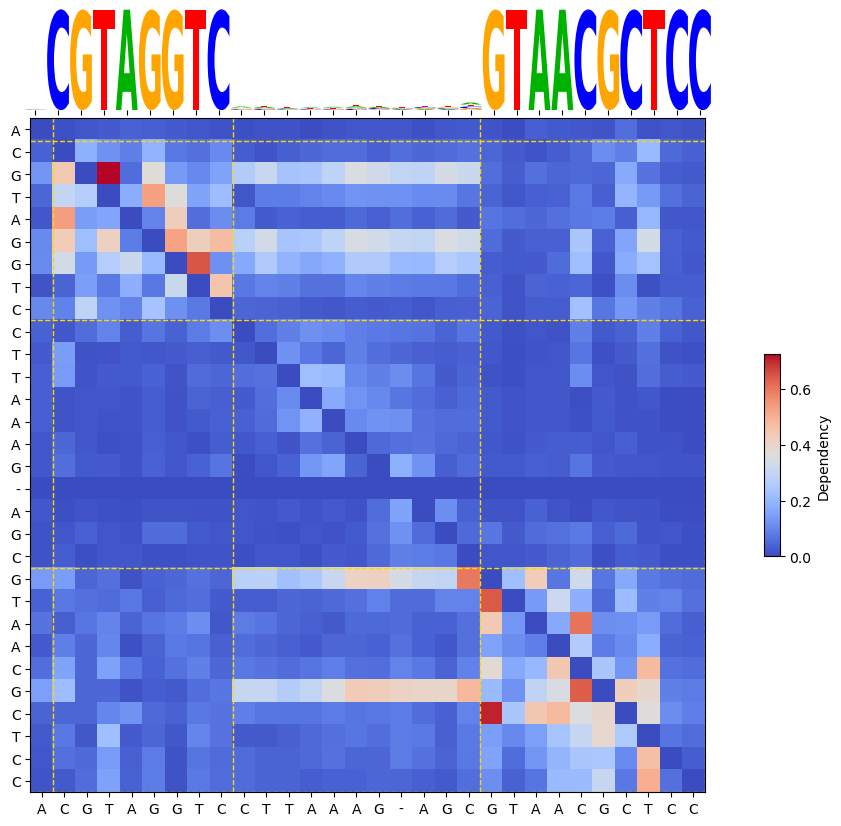

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logomaker

# -----------------------------
# dashed motif box helper
# -----------------------------
def draw_box(ax, start, length):
    end = start + length
    color = "gold"   # 연한 노란색 (히트맵 위에서 잘 보임)

    ax.axvline(start - 0.5, linestyle="--", linewidth=1, color=color)
    ax.axvline(end   - 0.5, linestyle="--", linewidth=1, color=color)
    ax.axhline(start - 0.5, linestyle="--", linewidth=1, color=color)
    ax.axhline(end   - 0.5, linestyle="--", linewidth=1, color=color)

df_logo = pd.DataFrame(logo_scores, columns=VOCAB_CHS)
df_logo.index = np.arange(SEQ_LEN)  

color_scheme = {"A":"#00b200", "C":"#0000ff", "G":"#ffa500", "T":"#ff0000", "-":"#7f7f7f"}

fig = plt.figure(figsize=(9, 9))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    height_ratios=[0.9, 6],     
    width_ratios=[20, 0.45],      
    hspace=0.02,
    wspace=0.15
)

ax_logo = fig.add_subplot(gs[0, 0])
ax_hm   = fig.add_subplot(gs[1, 0], sharex=ax_logo)   
cax     = fig.add_subplot(gs[1, 1])                   

logomaker.Logo(
    df_logo,
    ax=ax_logo,
    color_scheme=color_scheme,
    shade_below=0.0,
    fade_below=0.0
)

ax_logo.set_xlim(-0.5, SEQ_LEN - 0.5)   
ax_logo.set_xticks([])                
ax_logo.set_ylabel("")                 
ax_logo.set_yticks([])                  
for sp in ax_logo.spines.values():
    sp.set_visible(False)

vmax = np.percentile(D, 100)   
im = ax_hm.imshow(
    D,
    origin="upper",
    aspect="auto",
    vmin=0,
    vmax=vmax,
    cmap="coolwarm"   
)
ax_hm.set_aspect("equal", adjustable="box")

cb = fig.colorbar(im, cax=cax)
cb.set_label("Dependency")

ax_hm.set_xlabel("")
ax_hm.set_ylabel("")

xs = np.arange(SEQ_LEN)
ys = np.arange(SEQ_LEN)
ax_hm.set_xticks(xs)
ax_hm.set_yticks(ys)

ax_hm.set_xticklabels(list(seq_window), fontsize=10)
ax_hm.set_yticklabels(list(seq_window), fontsize=10)

draw_box(ax_hm, A_START, La)
draw_box(ax_hm, B_START, Lb)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.92)

pos = cax.get_position()
cax.set_position([
    pos.x0,                
    pos.y0 + pos.height*0.35,  
    pos.width,
    pos.height*0.3          
])

plt.show()

=== ORIGINAL (with gaps) ===
ACGTAGGTCCTTAAAG-AGCGTAACGCTCC
len: 30 | '-' count: 1

=== WINDOW USED ===
ACGTAGGTCCTTAAAG-AGCGTAACGCTCC
[gap-logodds-mean5] done target j 5/30
[gap-logodds-mean5] done target j 10/30
[gap-logodds-mean5] done target j 15/30
[gap-logodds-mean5] done target j 20/30
[gap-logodds-mean5] done target j 25/30
[gap-logodds-mean5] done target j 30/30
D shape: (30, 30) min/max: 0.0 0.5668939590454102


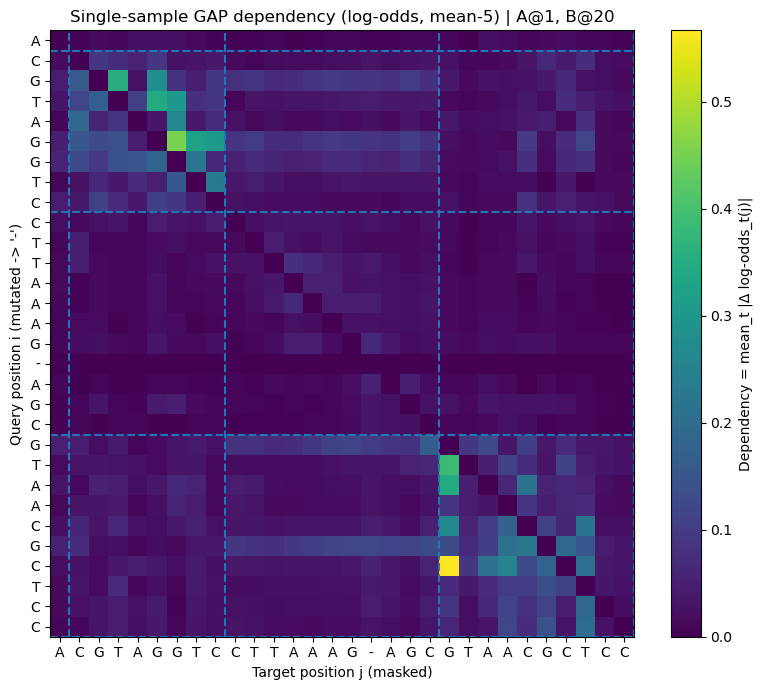

In [ ]:
# ===== SINGLE SAMPLE | A@1, B@20 | GAP-only mutation | 5-class LOG-ODDS dependency (MEAN over tokens) =====
import numpy as np
import torch
import matplotlib.pyplot as plt

SEQ_LEN   = 30
MAX_LEN   = 64
A_START   = 1
B_START   = 20

mask_id = int(tokenizer.mask_token_id)

# vocab ids (A,C,G,T,'-')
A_id   = int(tokenizer("A")["input_ids"][0][1])
C_id   = int(tokenizer("C")["input_ids"][0][1])
G_id   = int(tokenizer("G")["input_ids"][0][1])
T_id   = int(tokenizer("T")["input_ids"][0][1])
gap_id = int(tokenizer("-")["input_ids"][0][1])

VOCAB_IDS = [A_id, C_id, G_id, T_id, gap_id]
VOCAB_CHS = ["A", "C", "G", "T", "-"]

La, Lb = len(motif_a), len(motif_b)

def find_motif_pos(seq, motif):
    return seq.find(motif)

cands = []
for s in seqs:
    if find_motif_pos(s, motif_a) == A_START and find_motif_pos(s, motif_b) == B_START:
        cands.append(s)

if len(cands) == 0:
    raise ValueError(f"No sequence found with motif A@{A_START} and motif B@{B_START}.")

idx_pick = 0      
example_seq = cands[idx_pick]

print("=== ORIGINAL (with gaps) ===")
print(example_seq)
print("len:", len(example_seq), "| '-' count:", example_seq.count("-"))

seq_window = example_seq[:SEQ_LEN]
print("\n=== WINDOW USED ===")
print(seq_window)

subset = [example_seq]

@torch.no_grad()
def forward_logits(input_ids, attention_mask):
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    return out.logits if hasattr(out, "logits") else out[0]

def logit_from_logp(logp: torch.Tensor, eps: float = 1e-6):
    p = logp.exp()
    p = torch.clamp(p, eps, 1.0 - eps)
    return torch.log(p) - torch.log1p(-p)

def dependency_map_gap_logodds_mean5_single(
    seqs_subset,
    seq_len=SEQ_LEN,
    max_len=MAX_LEN,
    zero_diagonal=True,
    skip_if_i_already_gap=True,
):
    model.eval()
    assert len(seqs_subset) == 1

    D = np.zeros((seq_len, seq_len), dtype=np.float64)

    enc = tokenizer(seqs_subset, max_len, padding="max_length", return_tensors="pt")
    input_ids0 = enc["input_ids"].to(device)
    attn0      = enc["attention_mask"].to(device)

    # ---- baseline log-odds vectors [j, token] ----
    base_logodds = np.zeros((seq_len, len(VOCAB_IDS)))

    for j in range(seq_len):
        ids = input_ids0.clone()
        ids[:, j + 1] = mask_id

        logits = forward_logits(ids, attn0)
        logp   = torch.log_softmax(logits[:, j + 1, :], dim=-1)[0]

        for k, tid in enumerate(VOCAB_IDS):
            base_logodds[j, k] = float(logit_from_logp(logp[tid]).item())

    # ---- mutation i -> gap ----
    for j in range(seq_len):
        for i in range(seq_len):
            if i == j and zero_diagonal:
                D[i, j] = 0.0
                continue

            ids = input_ids0.clone()
            ids[:, j + 1] = mask_id

            orig_i = int(ids[0, i + 1].item())
            if skip_if_i_already_gap and orig_i == gap_id:
                D[i, j] = 0.0
                continue

            ids[0, i + 1] = gap_id

            logits = forward_logits(ids, attn0)
            logp   = torch.log_softmax(logits[:, j + 1, :], dim=-1)[0]

            mut_logodds = np.zeros((len(VOCAB_IDS),))
            for k, tid in enumerate(VOCAB_IDS):
                mut_logodds[k] = float(logit_from_logp(logp[tid]).item())

            # ★ 핵심 차이: MEAN
            D[i, j] = float(np.mean(np.abs(base_logodds[j] - mut_logodds)))

        if (j + 1) % 5 == 0:
            print(f"[gap-logodds-mean5] done target j {j+1}/{seq_len}")

    if zero_diagonal:
        np.fill_diagonal(D, 0.0)

    return D

# ---- compute ----
D = dependency_map_gap_logodds_mean5_single(subset)

print("D shape:", D.shape, "min/max:", float(D.min()), float(D.max()))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(D, aspect="auto", origin="upper")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Dependency = mean_t |Δ log-odds_t(j)|")

ax.set_xlabel("Target position j (masked)")
ax.set_ylabel("Query position i (mutated -> '-')")
ax.set_title(f"Single-sample GAP dependency (log-odds, mean-5) | A@{A_START}, B@{B_START}")

# axis letters
xs = list(range(SEQ_LEN))
ys = list(range(SEQ_LEN))
ax.set_xticks(xs)
ax.set_yticks(ys)
ax.set_xticklabels([seq_window[k] for k in xs], fontsize=10)
ax.set_yticklabels([seq_window[k] for k in ys], fontsize=10)

# motif boxes (dashed)
def draw_box(ax, start, length):
    end = start + length
    ax.axvline(start - 0.5, linestyle="--")
    ax.axvline(end   - 0.5, linestyle="--")
    ax.axhline(start - 0.5, linestyle="--")
    ax.axhline(end   - 0.5, linestyle="--")

draw_box(ax, A_START, La)
draw_box(ax, B_START, Lb)

plt.tight_layout()
plt.show()

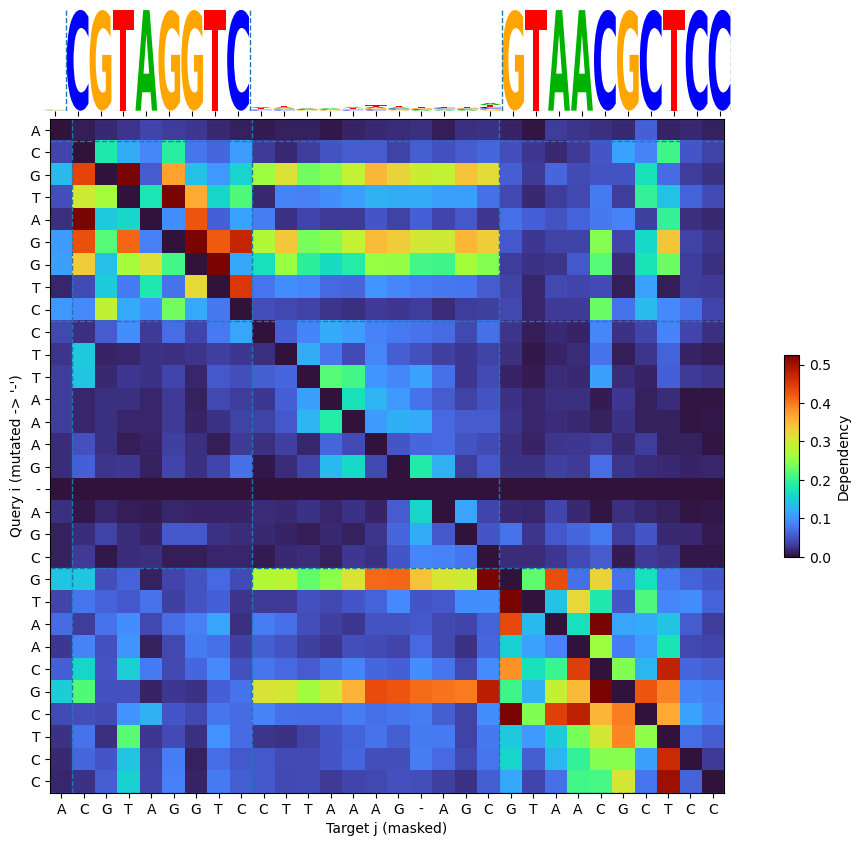

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logomaker

def draw_box(ax, start, length):
    end = start + length
    ax.axvline(start - 0.5, linestyle="--", linewidth=1)
    ax.axvline(end   - 0.5, linestyle="--", linewidth=1)
    ax.axhline(start - 0.5, linestyle="--", linewidth=1)
    ax.axhline(end   - 0.5, linestyle="--", linewidth=1)

df_logo = pd.DataFrame(logo_scores, columns=VOCAB_CHS)
df_logo.index = np.arange(SEQ_LEN) 

color_scheme = {"A":"#00b200", "C":"#0000ff", "G":"#ffa500", "T":"#ff0000", "-":"#7f7f7f"}

fig = plt.figure(figsize=(9, 9))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    height_ratios=[0.9, 6],     
    width_ratios=[20, 0.45],       
    hspace=0.02,
    wspace=0.15
)

ax_logo = fig.add_subplot(gs[0, 0])
ax_hm   = fig.add_subplot(gs[1, 0], sharex=ax_logo)   
cax     = fig.add_subplot(gs[1, 1])                   

logomaker.Logo(
    df_logo,
    ax=ax_logo,
    color_scheme=color_scheme,
    shade_below=0.0,
    fade_below=0.0
)

ax_logo.set_xlim(-0.5, SEQ_LEN - 0.5) 
ax_logo.set_xticks([])                  
ax_logo.set_ylabel("")                  
ax_logo.set_yticks([])                 
for sp in ax_logo.spines.values():
    sp.set_visible(False)


vmax = np.percentile(D, 99)  
im = ax_hm.imshow(
    D,
    origin="upper",
    aspect="auto",
    vmin=0,
    vmax=vmax,
    cmap="turbo"   
)
ax_hm.set_aspect("equal", adjustable="box")

cb = fig.colorbar(im, cax=cax)
cb.set_label("Dependency")

ax_hm.set_xlabel("Target j (masked)")
ax_hm.set_ylabel("Query i (mutated -> '-')")

xs = np.arange(SEQ_LEN)
ys = np.arange(SEQ_LEN)
ax_hm.set_xticks(xs)
ax_hm.set_yticks(ys)

ax_hm.set_xticklabels(list(seq_window), fontsize=10)
ax_hm.set_yticklabels(list(seq_window), fontsize=10)

draw_box(ax_hm, A_START, La)
draw_box(ax_hm, B_START, Lb)

fig.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.92)

pos = cax.get_position()
cax.set_position([
    pos.x0,               
    pos.y0 + pos.height*0.35,  
    pos.width,
    pos.height*0.3        
])

plt.show()

In [167]:
# ===== FINAL CELL (A-only sample) =====
import random
import numpy as np
import torch
from dependency_map import DependencyMap

def find_motif_pos(seq, motif):
    return seq.find(motif)

# -----------------------------
# 0) pick ONE seq that contains motif A ONLY (A present, B absent)
# -----------------------------
example_seq = None
pa = pb = -1
for s in seqs:
    pa_ = find_motif_pos(s, motif_a)
    pb_ = find_motif_pos(s, motif_b)
    if pa_ >= 0 and pb_ < 0:
        example_seq = s
        pa, pb = pa_, pb_
        break

if example_seq is None:
    raise ValueError("No example found with motif A only (A present, B absent).")

print("picked example len:", len(example_seq), "| A@", pa, "B@", pb, "| has '-':", ("-" in example_seq))

# -----------------------------
# 1) dependency-map requires A/C/G/T only -> replace gaps
# -----------------------------
def replace_gaps_random(seq, seed=0):
    rng = random.Random(seed)
    return "".join(rng.choice("ACGT") if ch == "-" else ch for ch in seq)

example_seq_nogap = replace_gaps_random(example_seq, seed=0)

# -----------------------------
# 2) choose window length (you said 30)
# -----------------------------
L = 30
seq_clean = example_seq_nogap[:L]
assert len(seq_clean) == L
print("window len:", len(seq_clean))
print("window seq:", seq_clean)

MAX_LEN = L + 2
BATCH_SIZE = 64

mask_id = int(tokenizer.mask_token_id)

A_id = int(tokenizer("A")["input_ids"][0][1])
C_id = int(tokenizer("C")["input_ids"][0][1])
G_id = int(tokenizer("G")["input_ids"][0][1])
T_id = int(tokenizer("T")["input_ids"][0][1])
ACGT_IDS = torch.tensor([A_id, C_id, G_id, T_id], device=device, dtype=torch.long)

def _as_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def normalize_mask(mask, L, T):
    if mask is None:
        return None

    m = _as_np(mask)

    if m.shape == ():
        out = np.zeros(T, dtype=bool)
        idx = int(m.item())
        if 0 <= idx < T:
            out[idx] = True
            return out
        if 0 <= idx < L:
            out[idx + 1] = True
            return out
        return out

    m = np.asarray(m)

    if np.issubdtype(m.dtype, np.integer):
        out = np.zeros(T, dtype=bool)
        for idx in m.reshape(-1).tolist():
            idx = int(idx)
            if 0 <= idx < T:
                out[idx] = True
            elif 0 <= idx < L:
                out[idx + 1] = True
        return out

    m = m.astype(bool).reshape(-1)

    out = np.zeros(T, dtype=bool)

    if len(m) == T:
        out[:] = m
        return out
    if len(m) == L:
        out[1:1+L] = m
        return out
    if len(m) == L + 1:
        out[:L+1] = m[:L+1]
        return out

    out[: min(T, len(m))] = m[: min(T, len(m))]
    return out

def tokenize_fn(seq, mask=None, **kwargs):
    if isinstance(seq, (list, tuple)) and len(seq) > 0:
        seq = seq[0]
    seq = seq[:L].ljust(L, "A")

    enc = tokenizer(seq, MAX_LEN, padding="max_length", return_tensors="pt")
    input_ids = enc["input_ids"].clone()
    attention_mask = enc["attention_mask"]
    T = input_ids.shape[1]

    token_mask = normalize_mask(mask, L=L, T=T)
    if token_mask is not None and token_mask.any():
        idxs = np.where(token_mask)[0]
        idxs = idxs[(idxs >= 0) & (idxs < T)]
        if len(idxs) > 0:
            input_ids[0, idxs] = mask_id

    return {"input_ids": input_ids.to(device), "attention_mask": attention_mask.to(device)}

@torch.no_grad()
def forward_fn(batch):
    if isinstance(batch, dict):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
    else:
        input_ids = torch.cat([b["input_ids"] for b in batch], dim=0)
        attention_mask = torch.cat([b["attention_mask"] for b in batch], dim=0)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits_full = out.logits if hasattr(out, "logits") else out[0]

    logits_seq = logits_full[:, 1:1+L, :]
    logits_4 = logits_seq.index_select(dim=-1, index=ACGT_IDS)
    return logits_4.detach().cpu().numpy()

print("Computing with DependencyMap.compute_batched (A-only sample) ...")
dm = DependencyMap.compute_batched(seq_clean, tokenize_fn, forward_fn, BATCH_SIZE)

print("Done. Plotting...")
dm.plot()

picked example len: 30 | A@ 7 B@ -1 | has '-': True
window len: 30
window seq: TCTCTGTCGTAGGTCCCTAAACGGCTCTGG
Computing with DependencyMap.compute_batched (A-only sample) ...


100%|██████████| 2/2 [00:02<00:00,  1.00s/it]


Done. Plotting...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'colorscale': [[0.0, 'rgb(58,76,192)'], [0.003937007874015748,
                             'rgb(59,77,193)'], [0.007874015748031496,
                             'rgb(60,79,195)'], ..., [0.9921259842519685,
                             'rgb(182,13,40)'], [0.9960629921259843,
                             'rgb(181,8,39)'], [1.0, 'rgb(179,3,38)']],
              'type': 'heatmap',
              'x': {'bdata': 'AAECAwQFBgcICQoLDA0ODxAREhMUFRYXGBkaGxwd', 'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': 'AAECAwQFBgcICQoLDA0ODxAREhMUFRYXGBkaGxwd', 'dtype': 'i1'},
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAAAAAACAbwk0pnGmP4B8DZcLzZ' ... 'Ng5KGDsz8gfMK54bmjPwAAAAAAAAAA'),
                    'dtype': 'f8',
                    'shape': '30, 30'}}],
    'layout': {'images': [{'sizex': 30,
                           'sizey': 0.1,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'JHIiAvPgo8L2c+CjwvZz4KPC9zdmc+'),
                           'x': -0.5,
                           'xanchor': 'left',
                           'xref': 'x',
                           'y': 1.0,
                           'yanchor': 'bottom',
                           'yref': 'y domain'},
                          {'sizex': 0.05,
                           'sizey': 30,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'ciIC8+CjwvZz4KPC9nPgo8L3N2Zz4='),
                           'x': 0.0,
                           'xanchor': 'right',
                           'xref': 'x domain',
                           'y': 29.5,
                           'yanchor': 'bottom',
                           'yref': 'y'},
                          {'sizex': 30,
                           'sizey': 0.05,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'IgLz4KPC9nPgo8L2c+Cjwvc3ZnPg=='),
                           'x': -0.5,
                           'xanchor': 'left',
                           'xref': 'x',
                           'y': 0.0,
                           'yanchor': 'top',
                           'yref': 'y domain'},
                          {'sizex': 0.1,
                           'sizey': 30,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'IgLz4KPC9nPgo8L2c+Cjwvc3ZnPg=='),
                           'x': 1.0,
                           'xanchor': 'left',
                           'xref': 'x domain',
                           'y': -0.5,
                           'yanchor': 'top',
                           'yref': 'y'}],
               'template': '...',
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y', 'visible': False},
               'yaxis': {'anchor': 'x',
                         'autorange': 'reversed',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'scaleanchor': 'x',
                         'visible': False}}
})

In [171]:
# ===== FINAL CELL (B-only sample) =====
import random
import numpy as np
import torch
from dependency_map import DependencyMap

def find_motif_pos(seq, motif):
    return seq.find(motif)

# -----------------------------
# 0) pick ONE seq that contains motif B ONLY (B present, A absent)
# -----------------------------
example_seq = None
pa = pb = -1
for s in seqs:
    pa_ = find_motif_pos(s, motif_a)
    pb_ = find_motif_pos(s, motif_b)
    if pb_ >= 10 and pa_ < 10:
        example_seq = s
        pa, pb = pa_, pb_
        break

if example_seq is None:
    raise ValueError("No example found with motif B only (B present, A absent).")

print("picked example len:", len(example_seq), "| A@", pa, "B@", pb, "| has '-':", ("-" in example_seq))

# -----------------------------
# 1) dependency-map requires A/C/G/T only -> replace gaps
# -----------------------------
def replace_gaps_random(seq, seed=0):
    rng = random.Random(seed)
    return "".join(rng.choice("ACGT") if ch == "-" else ch for ch in seq)

example_seq_nogap = replace_gaps_random(example_seq, seed=0)

# -----------------------------
# 2) choose window length (you said 30)
# -----------------------------
L = 30
seq_clean = example_seq_nogap[:L]
assert len(seq_clean) == L
print("window len:", len(seq_clean))
print("window seq:", seq_clean)

MAX_LEN = L + 2
BATCH_SIZE = 64

mask_id = int(tokenizer.mask_token_id)

A_id = int(tokenizer("A")["input_ids"][0][1])
C_id = int(tokenizer("C")["input_ids"][0][1])
G_id = int(tokenizer("G")["input_ids"][0][1])
T_id = int(tokenizer("T")["input_ids"][0][1])
ACGT_IDS = torch.tensor([A_id, C_id, G_id, T_id], device=device, dtype=torch.long)

def _as_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def normalize_mask(mask, L, T):
    if mask is None:
        return None

    m = _as_np(mask)

    if m.shape == ():
        out = np.zeros(T, dtype=bool)
        idx = int(m.item())
        if 0 <= idx < T:
            out[idx] = True
            return out
        if 0 <= idx < L:
            out[idx + 1] = True
            return out
        return out

    m = np.asarray(m)

    if np.issubdtype(m.dtype, np.integer):
        out = np.zeros(T, dtype=bool)
        for idx in m.reshape(-1).tolist():
            idx = int(idx)
            if 0 <= idx < T:
                out[idx] = True
            elif 0 <= idx < L:
                out[idx + 1] = True
        return out

    m = m.astype(bool).reshape(-1)

    out = np.zeros(T, dtype=bool)

    if len(m) == T:
        out[:] = m
        return out
    if len(m) == L:
        out[1:1+L] = m
        return out
    if len(m) == L + 1:
        out[:L+1] = m[:L+1]
        return out

    out[: min(T, len(m))] = m[: min(T, len(m))]
    return out

def tokenize_fn(seq, mask=None, **kwargs):
    if isinstance(seq, (list, tuple)) and len(seq) > 0:
        seq = seq[0]
    seq = seq[:L].ljust(L, "A")

    enc = tokenizer(seq, MAX_LEN, padding="max_length", return_tensors="pt")
    input_ids = enc["input_ids"].clone()
    attention_mask = enc["attention_mask"]
    T = input_ids.shape[1]

    token_mask = normalize_mask(mask, L=L, T=T)
    if token_mask is not None and token_mask.any():
        idxs = np.where(token_mask)[0]
        idxs = idxs[(idxs >= 0) & (idxs < T)]
        if len(idxs) > 0:
            input_ids[0, idxs] = mask_id

    return {"input_ids": input_ids.to(device), "attention_mask": attention_mask.to(device)}

@torch.no_grad()
def forward_fn(batch):
    if isinstance(batch, dict):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
    else:
        input_ids = torch.cat([b["input_ids"] for b in batch], dim=0)
        attention_mask = torch.cat([b["attention_mask"] for b in batch], dim=0)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits_full = out.logits if hasattr(out, "logits") else out[0]

    logits_seq = logits_full[:, 1:1+L, :]
    logits_4 = logits_seq.index_select(dim=-1, index=ACGT_IDS)
    return logits_4.detach().cpu().numpy()

print("Computing with DependencyMap.compute_batched (B-only sample) ...")
dm = DependencyMap.compute_batched(seq_clean, tokenize_fn, forward_fn, BATCH_SIZE)

print("Done. Plotting...")
dm.plot()

picked example len: 30 | A@ -1 B@ 14 | has '-': True
window len: 30
window seq: GTGTCCGGATTAAAGTAACGCTCCCCATGG
Computing with DependencyMap.compute_batched (B-only sample) ...


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  5.21it/s]


Done. Plotting...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'colorscale': [[0.0, 'rgb(58,76,192)'], [0.003937007874015748,
                             'rgb(59,77,193)'], [0.007874015748031496,
                             'rgb(60,79,195)'], ..., [0.9921259842519685,
                             'rgb(182,13,40)'], [0.9960629921259843,
                             'rgb(181,8,39)'], [1.0, 'rgb(179,3,38)']],
              'type': 'heatmap',
              'x': {'bdata': 'AAECAwQFBgcICQoLDA0ODxAREhMUFRYXGBkaGxwd', 'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': 'AAECAwQFBgcICQoLDA0ODxAREhMUFRYXGBkaGxwd', 'dtype': 'i1'},
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAAAAAADAoLfAdGawP4B+FZOpaJ' ... 'cuQccMpT8A47igQkCOPwAAAAAAAAAA'),
                    'dtype': 'f8',
                    'shape': '30, 30'}}],
    'layout': {'images': [{'sizex': 30,
                           'sizey': 0.1,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'ciIC8+CjwvZz4KPC9nPgo8L3N2Zz4='),
                           'x': -0.5,
                           'xanchor': 'left',
                           'xref': 'x',
                           'y': 1.0,
                           'yanchor': 'bottom',
                           'yref': 'y domain'},
                          {'sizex': 0.05,
                           'sizey': 30,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'ciIC8+CjwvZz4KPC9nPgo8L3N2Zz4='),
                           'x': 0.0,
                           'xanchor': 'right',
                           'xref': 'x domain',
                           'y': 29.5,
                           'yanchor': 'bottom',
                           'yref': 'y'},
                          {'sizex': 30,
                           'sizey': 0.05,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'IgLz4KPC9nPgo8L2c+Cjwvc3ZnPg=='),
                           'x': -0.5,
                           'xanchor': 'left',
                           'xref': 'x',
                           'y': 0.0,
                           'yanchor': 'top',
                           'yref': 'y domain'},
                          {'sizex': 0.1,
                           'sizey': 30,
                           'sizing': 'stretch',
                           'source': ('data:image/svg+xml;base64,PD94' ... 'JHIiAvPgo8L2c+CjwvZz4KPC9zdmc+'),
                           'x': 1.0,
                           'xanchor': 'left',
                           'xref': 'x domain',
                           'y': -0.5,
                           'yanchor': 'top',
                           'yref': 'y'}],
               'template': '...',
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y', 'visible': False},
               'yaxis': {'anchor': 'x',
                         'autorange': 'reversed',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'scaleanchor': 'x',
                         'visible': False}}
})

In [121]:
from collections import Counter

import numpy as np


def find_motif_pos(seq, motif):
    return seq.find(motif)


# collect motif B start positions
b_pos = [find_motif_pos(s, motif_b) for s in seqs]
b_pos = [p for p in b_pos if p >= 0]

print("Total sequences:", len(seqs))
print("Sequences containing motif B:", len(b_pos))

pos_counts = Counter(b_pos)
print("Unique motif B start positions:", len(pos_counts))

# show top positions
for p, c in pos_counts.most_common(10):
    print(f"b_start={p:2d}  count={c}")

# (optional) pick a few positions to visualize later
top_positions = [p for p, c in pos_counts.most_common(4)]
print("Top positions:", top_positions)

Total sequences: 20000
Sequences containing motif B: 11496
Unique motif B start positions: 21
b_start=20  count=2200
b_start=19  count=1328
b_start=18  count=634
b_start=17  count=439
b_start= 0  count=439
b_start=15  count=430
b_start=11  count=430
b_start= 5  count=417
b_start= 1  count=415
b_start=10  count=414
Top positions: [20, 19, 18, 17]


In [34]:
import numpy as np
import torch
import torch.nn.functional as F

SEQ_LEN = 40
MAX_LEN = 64
BATCH_SIZE = 32

mask_id = tokenizer.mask_token_id

# token ids for A/C/G/T (query substitutions)
A_id = tokenizer("A")["input_ids"][0][1]
C_id = tokenizer("C")["input_ids"][0][1]
G_id = tokenizer("G")["input_ids"][0][1]
T_id = tokenizer("T")["input_ids"][0][1]
DNA_IDS = torch.tensor([A_id, C_id, G_id, T_id], device=device)
DNA_CHS = ["A", "C", "G", "T"]


def dependency_map_substitution(seqs_subset, batch_size=BATCH_SIZE):
    """
    D[i,j] = max_s | logP(true_j | original, mask j) - logP(true_j | mutate i->s, mask j) |
    where s runs over A/C/G/T excluding original base at i.
    """
    model.eval()
    N = len(seqs_subset)
    D = np.zeros((SEQ_LEN, SEQ_LEN), dtype=np.float64)

    # tokenize once
    enc = tokenizer(seqs_subset, MAX_LEN, padding="max_length", return_tensors="pt")
    input_ids0 = enc["input_ids"].to(device)  # [N, L]
    attn0 = enc["attention_mask"].to(device)

    # true token ids at each char position (shift +1 for CLS)
    true_ids = input_ids0[:, 1 : 1 + SEQ_LEN]  # [N, SEQ_LEN]

    # helper to get logP(true_j) when j is masked (optionally with i mutated)
    def batch_logp_truej(ids_batch, attn_batch, truej_ids_batch, j_char):
        """
        ids_batch: [B,L]
        truej_ids_batch: [B]  (true token id at position j)
        returns: logP(true_j) [B]
        """
        j_tok = j_char + 1
        with torch.no_grad():
            out = model(input_ids=ids_batch, attention_mask=attn_batch)
        logits = out.logits if hasattr(out, "logits") else out[0]  # [B,L,V]
        logp = torch.log_softmax(logits[:, j_tok, :], dim=-1)  # [B,V]
        return logp.gather(1, truej_ids_batch.unsqueeze(1)).squeeze(1)  # [B]

    # loop over target j (mask position)
    for j in range(SEQ_LEN):
        # baseline: mask j only
        base_logps = []

        for s in range(0, N, batch_size):
            ids = input_ids0[s : s + batch_size].clone()
            attn = attn0[s : s + batch_size]
            truej = true_ids[s : s + batch_size, j]

            j_tok = j + 1
            ids[:, j_tok] = mask_id  # mask target

            lp = batch_logp_truej(ids, attn, truej, j_char=j)
            base_logps.append(lp.detach().cpu())

        base_logps = torch.cat(base_logps, dim=0)  # [N]

        # loop over query i
        for i in range(SEQ_LEN):
            # if i == j, skip or allow (usually skip)
            if i == j:
                D[i, j] = 0.0
                continue

            # compute max over substitutions
            max_delta = None

            for alt_id in DNA_IDS:
                deltas = []

                for s in range(0, N, batch_size):
                    ids = input_ids0[s : s + batch_size].clone()
                    attn = attn0[s : s + batch_size]
                    truej = true_ids[s : s + batch_size, j]

                    # skip sequences where query i is not A/C/G/T (e.g., gap)
                    qi = true_ids[s : s + batch_size, i]  # [B]
                    # only keep rows where qi is in DNA_IDS
                    is_dna = (qi.unsqueeze(1) == DNA_IDS.unsqueeze(0)).any(dim=1)

                    if not is_dna.any():
                        continue

                    # apply target mask
                    ids[:, j + 1] = mask_id

                    # mutate query i to alt, but only for rows where:
                    # 1) query is DNA
                    # 2) alt != original
                    orig_tok = ids[:, i + 1]
                    can_mut = is_dna & (orig_tok != alt_id)

                    ids[can_mut, i + 1] = alt_id

                    lp_mut = batch_logp_truej(ids, attn, truej, j_char=j).detach().cpu()
                    # delta only meaningful for rows we actually mutated
                    delta = (base_logps[s : s + batch_size] - lp_mut).abs()
                    delta = delta[can_mut.cpu()]

                    if len(delta) > 0:
                        deltas.append(delta)

                if len(deltas) == 0:
                    continue

                deltas = torch.cat(deltas, dim=0)
                cand = float(deltas.mean().item())

                max_delta = cand if (max_delta is None) else max(max_delta, cand)

            D[i, j] = 0.0 if (max_delta is None) else max_delta

        if (j + 1) % 5 == 0:
            print(f"done target j {j+1}/{SEQ_LEN}")

    return D

In [36]:
from collections import defaultdict

groups = defaultdict(list)

for s in seqs:
    p = find_motif_pos(s, motif_b)
    if p >= 0:
        groups[p].append(s)

print("Example group sizes:")
for k in sorted(groups)[:5]:
    print(k, len(groups[k]))

Example group sizes:
0 17
1 16
2 18
3 24
4 19


b_start = 34
subset = groups[b_start][:200]  
D = dependency_map_substitution(subset)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(D, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j")
plt.ylabel("Query position i")
plt.title(f"Substitution dependency map | motif B start={b_start} | n={len(subset)}")
plt.show()

In [ ]:
# --- pick one sequence that contains BOTH motifs A and B ---
def find_motif_pos(seq, motif):
    return seq.find(motif)

candidates = []
for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)
    if pa >= 0 and pb >= 0:
        candidates.append((s, pa, pb))

print("num candidates (A & B):", len(candidates))

idx = 0
s_one, pa, pb = candidates[idx]

print("\nSELECTED SEQ:", s_one)
print("len:", len(s_one))
print("motif A start:", pa, "motif:", motif_a)
print("motif B start:", pb, "motif:", motif_b)

def mark(seq, spans):
    spans = sorted(spans, key=lambda x: x[0])
    out = []
    last = 0
    for st, ln, tag in spans:
        out.append(seq[last:st])
        out.append(f"[{tag}:{seq[st:st+ln]}]")
        last = st + ln
    out.append(seq[last:])
    return "".join(out)

print("marked:", mark(s_one, [(pa, len(motif_a), "A"), (pb, len(motif_b), "B")]))

num candidates (A & B): 754

SELECTED SEQ: ACAGGG-CGGCGGAGCACTAGGTAGG-TACGAAGATCTTA
len: 40
motif A start: 16 motif: ACTAGGT
motif B start: 34 motif: ATCTTA
marked: ACAGGG-CGGCGGAGC[A:ACTAGGT]AGG-TACGAAG[B:ATCTTA]


done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


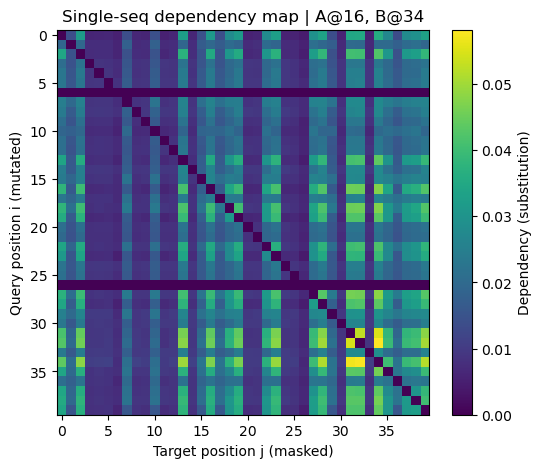

In [39]:
# --- single-seq dependency map ---
subset_one = [s_one]  # N=1 list로 넣어야 함
D_one = dependency_map_substitution(subset_one, batch_size=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(D_one, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked)")
plt.ylabel("Query position i (mutated)")
plt.title(f"Single-seq dependency map | A@{pa}, B@{pb}")
plt.show()

Num (A_start, B_start) groups: 92
Top 10 groups:
(A=17, B=34)  count=30
(A=15, B=32)  count=29
(A=13, B=30)  count=27
(A=14, B=31)  count=26
(A=16, B=33)  count=25
(A=16, B=34)  count=24
(A=14, B=32)  count=22
(A= 8, B=25)  count=20
(A=13, B=31)  count=20
(A= 6, B=23)  count=19

Running group (A=17, B=34) | using n=30 / total=30
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


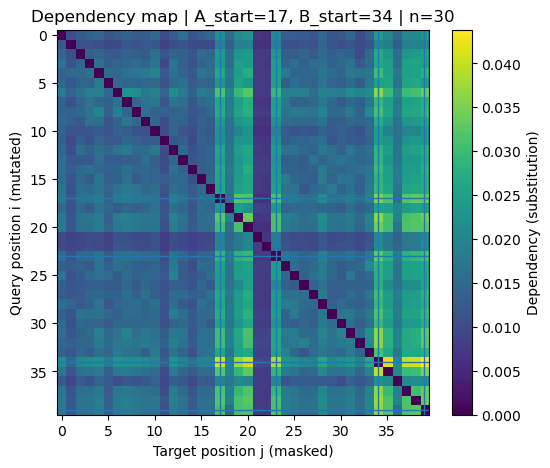


Running group (A=15, B=32) | using n=29 / total=29
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


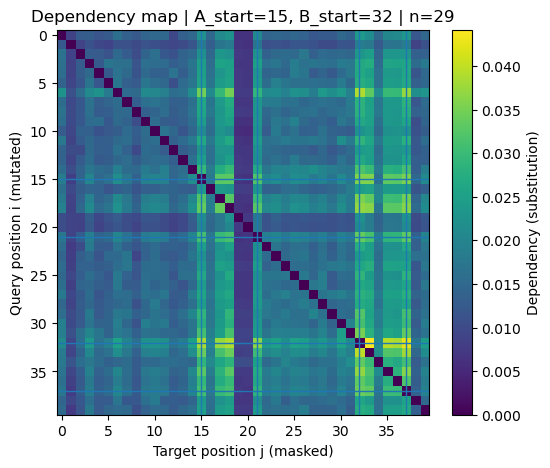


Running group (A=13, B=30) | using n=27 / total=27
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


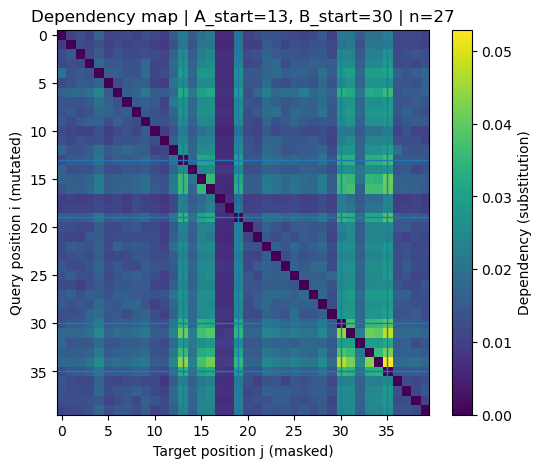


Running group (A=14, B=31) | using n=26 / total=26
done target j 5/40
done target j 10/40
done target j 15/40
done target j 20/40
done target j 25/40
done target j 30/40
done target j 35/40
done target j 40/40


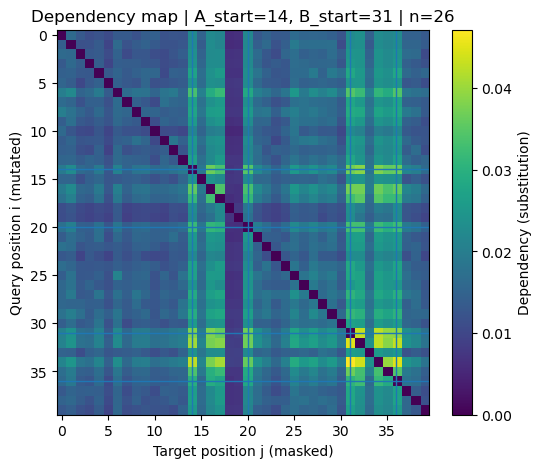

In [40]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

def find_motif_pos(seq, motif):
    return seq.find(motif)

# 1) Build groups by (A_start, B_start)
groups_ab = defaultdict(list)

for s in seqs:
    pa = find_motif_pos(s, motif_a)
    pb = find_motif_pos(s, motif_b)

    # keep only sequences where BOTH motifs exist
    if pa >= 0 and pb >= 0:
        # optional: enforce order (B after A). If you don't want it, remove this line.
        if pb <= pa:
            continue
        groups_ab[(pa, pb)].append(s)

print("Num (A_start, B_start) groups:", len(groups_ab))

# show top groups
counts = sorted([(k, len(v)) for k, v in groups_ab.items()], key=lambda x: x[1], reverse=True)
print("Top 10 groups:")
for (pa, pb), c in counts[:10]:
    print(f"(A={pa:2d}, B={pb:2d})  count={c}")

# 2) Pick top-k groups and plot dependency maps
TOP_K = 4
N_PER_GROUP = 200   # start small (100~200). can increase later.

top_groups = counts[:TOP_K]

a_len = len(motif_a)
b_len = len(motif_b)

for (pa, pb), total_c in top_groups:
    subset = groups_ab[(pa, pb)][:N_PER_GROUP]
    print(f"\nRunning group (A={pa}, B={pb}) | using n={len(subset)} / total={total_c}")

    D = dependency_map_substitution(subset, batch_size=32)

    plt.figure(figsize=(6,5))
    plt.imshow(D, aspect="auto")
    plt.colorbar(label="Dependency (substitution)")
    plt.xlabel("Target position j (masked)")
    plt.ylabel("Query position i (mutated)")
    plt.title(f"Dependency map | A_start={pa}, B_start={pb} | n={len(subset)}")

    # --- mark motif A & B spans on both axes ---
    # vertical = target j
    plt.axvline(pa, linewidth=1)
    plt.axvline(pa + a_len - 1, linewidth=1)
    plt.axvline(pb, linewidth=1)
    plt.axvline(pb + b_len - 1, linewidth=1)

    # horizontal = query i
    plt.axhline(pa, linewidth=1)
    plt.axhline(pa + a_len - 1, linewidth=1)
    plt.axhline(pb, linewidth=1)
    plt.axhline(pb + b_len - 1, linewidth=1)

    plt.show()

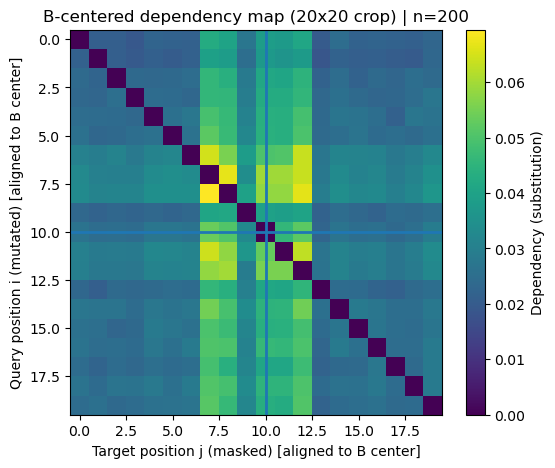

In [48]:
import matplotlib.pyplot as plt

# ---- crop to 20x20 without recomputing ----
D20 = D_Bcenter[:20, :20]   # drop the last row/col (from 21 -> 20)

plt.figure(figsize=(6,5))
plt.imshow(D20, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked) [aligned to B center]")
plt.ylabel("Query position i (mutated) [aligned to B center]")
plt.title("B-centered dependency map (20x20 crop) | n=200")

# In the 21x21 plot, center is at index LEFT=10.
# After cropping to 20, center is still at 10 (valid index).
plt.axvline(LEFT, linewidth=2)
plt.axhline(LEFT, linewidth=2)

plt.show()

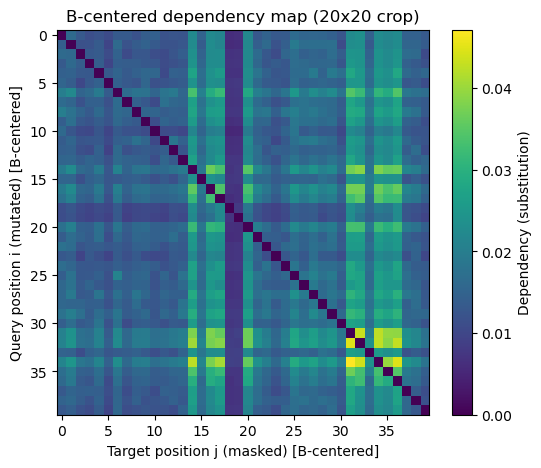

In [47]:
import matplotlib.pyplot as plt



D20 = D[:40, :40]

plt.figure(figsize=(6,5))
plt.imshow(D20, aspect="auto")
plt.colorbar(label="Dependency (substitution)")
plt.xlabel("Target position j (masked) [B-centered]")
plt.ylabel("Query position i (mutated) [B-centered]")
plt.title("B-centered dependency map (20x20 crop)")
plt.show()